# Baseline Report — Business Rehearsal Outcome Predictor
**Spring 2026 · Augmented Intelligence**

Pre-optimisation snapshot across all three models (Ridge, XGBoost, FT-Transformer)
evaluated on the same temporal 80/20 split.

| Section | What it measures |
|---|---|
| 1. Accuracy metrics | MAPE, RMSE, PICP, MPIW, NMPIW |
| 2. Directional accuracy | Did the model predict the right sign? |
| 3. Predicted vs actual | Visual scatter fit |
| 4. Residual analysis | Bias, spread, normality |
| 5. Train vs test | Overfitting check |
| 6. Temporal drift | Does accuracy hold over the test window? |
| 7. Per-scenario breakdown | Which branch types are hardest? |
| 8. Prediction intervals | Coverage and width |
| 9. SHAP importance | What features drive XGBoost? |
| 10. Relevance assessment | Do results address the design need? |

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (14, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

from models.baseline          import load_features, temporal_split, train_baseline, get_X_y, mape as _mape
from models.xgboost_model     import train_xgboost
from models.transformer_model import train_transformer
from evaluation.metrics       import evaluate_all_models, print_metrics_table, plot_calibration, plot_interval_widths, plot_mape

TARGETS = [
    'label_inventory_delta',
    'label_cashflow_delta',
    'label_order_velocity_delta',
]
SHORT = {
    'label_inventory_delta':      'Inventory',
    'label_cashflow_delta':       'Cash Flow',
    'label_order_velocity_delta': 'Order Velocity',
}
MODELS  = ['Baseline', 'XGBoost', 'Transformer']
COLORS  = {'Baseline': '#4C72B0', 'XGBoost': '#DD8452', 'Transformer': '#55A868'}

In [2]:
df = load_features('data/processed/training_data.csv')
train, test = temporal_split(df)

print('Training all three models...')
bl = train_baseline(train, test);    print('  Baseline done')
xg = train_xgboost(train, test);     print('  XGBoost done')
tr = train_transformer(train, test); print('  Transformer done')

all_results = {'Baseline': bl, 'XGBoost': xg, 'Transformer': tr}
print('All models trained.')

Loaded 2,100 rows from data/processed/training_data.csv
  Date range: 2025-11-30 → 2026-08-17
  Businesses: 150
  Branches:   2,100

Temporal split at 2026-06-26 (80%/20%)
  Train rows: 1,677  |  Test rows: 423
Training all three models...
  Baseline done

Training: inventory
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: cashflow
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: order_velocity
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done
  XGBoost done

Training: inventory  (73 features, device=mps)
  epoch    1  loss=16929.4157  val_mape=171.4%  best=171.4%
  epoch   20  loss=1486.6074  val_mape=91.1%  best=50.1%
  epoch   40  loss=388.5434  val_mape=33.0%  best=32.7%
  epoch   60  loss=253.2055  val_mape=39.9%  best=31.5%
  early stop at epoch 65  (no improvement for 20 epochs)

Training: cashflow  (73 features, device=mps)
  epoch    1  loss=55127798.3607  val_mape=100.0%  best=

---
## 1. Accuracy Metrics
MAPE and RMSE measure point-prediction accuracy.
PICP measures how often the true value falls inside the 80% prediction interval (target: 0.80).
MPIW / NMPIW measure interval width — tighter intervals are more useful to founders.

In [3]:
ev = evaluate_all_models(all_results)
print_metrics_table(ev)


MAPE (%)
Model           Baseline  Transformer  XGBoost
Target                                        
Cash Flow          134.7         97.8     90.9
Inventory          320.4         43.0    123.4
Order Velocity     127.8         61.0     90.5

RMSE
Model           Baseline  Transformer  XGBoost
Target                                        
Cash Flow        1180.73      6502.44  1029.04
Inventory          19.35        26.37    20.82
Order Velocity      4.77         4.62     4.08

PICP
  (target: 0.8)
Model           Baseline  Transformer  XGBoost
Target                                        
Cash Flow          0.913        0.007    0.754
Inventory          0.891        0.754    0.681
Order Velocity     0.820        0.764    0.697

MPIW
Model           Baseline  Transformer  XGBoost
Target                                        
Cash Flow        3544.47        26.03  2355.10
Inventory          44.38        44.23    22.88
Order Velocity     11.36         7.85     7.56

NMPIW
Model    

In [ ]:
plot_mape(all_results)
plot_calibration(all_results)
plot_interval_widths(all_results)

---
## 2. Directional Accuracy ("Confusion Matrix")
For a founder, the most actionable signal is the *direction* of impact:
will my inventory go up or down after this scenario?

We binarise predictions and actuals by sign and compute a 2×2 confusion matrix:
rows = actual direction, columns = predicted direction.

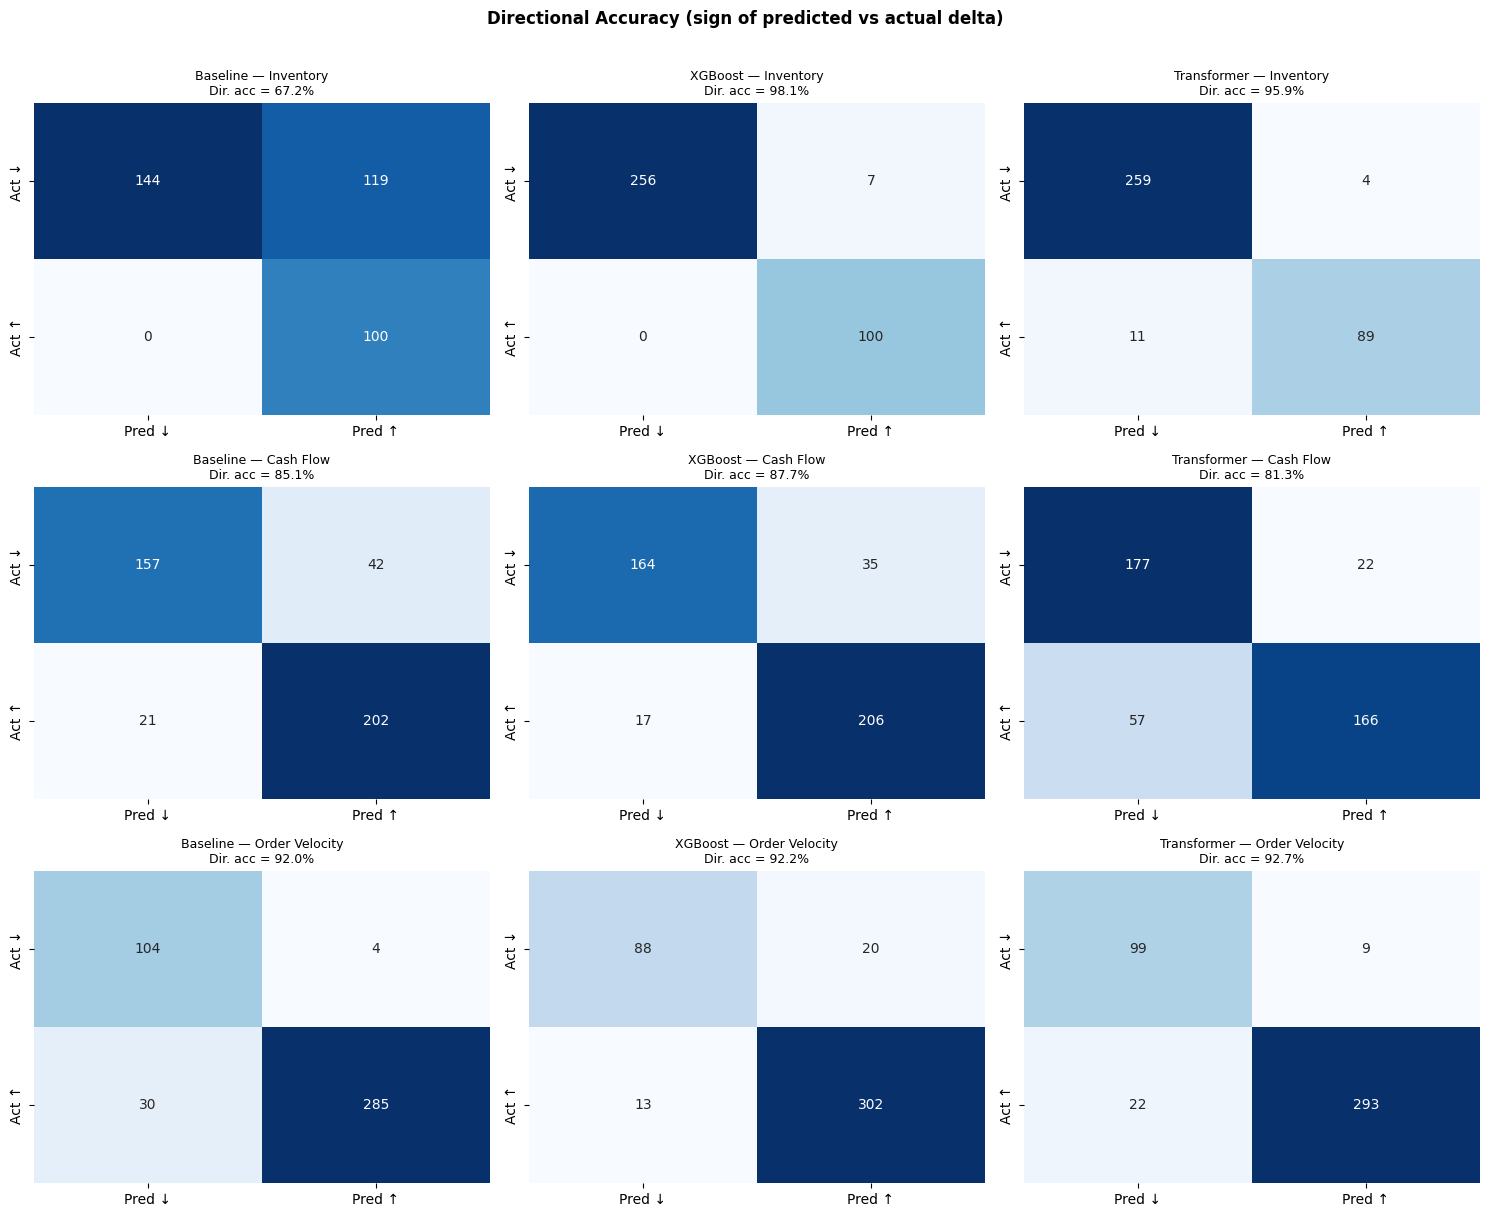


Directional accuracy summary:
  Target              Baseline      XGBoost       Transformer 
  ------------------------------------------------------------
  Inventory           67.2%        98.1%        95.9%      
  Cash Flow           85.1%        87.7%        81.3%      
  Order Velocity      92.0%        92.2%        92.7%      


In [4]:
def directional_accuracy(y_true, y_pred):
    """Fraction of samples where predicted sign matches actual sign."""
    mask = np.abs(y_true) > 1e-6          # exclude near-zero actuals
    return np.mean(np.sign(y_true[mask]) == np.sign(y_pred[mask]))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for col, (model_name, results) in enumerate(all_results.items()):
    for row, target in enumerate(TARGETS):
        ax   = axes[row][col]
        r    = results[target]
        mask = np.abs(r['y_test']) > 1e-6

        y_true_bin = (r['y_test'][mask] > 0).astype(int)
        y_pred_bin = (r['y_pred'][mask] > 0).astype(int)
        cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])

        acc = directional_accuracy(r['y_test'], r['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Pred ↓', 'Pred ↑'],
                    yticklabels=['Act ↓',  'Act ↑'],
                    cbar=False)
        ax.set_title(f'{model_name} — {SHORT[target]}\nDir. acc = {acc:.1%}', fontsize=9)

plt.suptitle('Directional Accuracy (sign of predicted vs actual delta)',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('\nDirectional accuracy summary:')
header = f"  {'Target':<18}" + ''.join(f"  {m:<12}" for m in MODELS)
print(header)
print('  ' + '-' * (len(header) - 2))
for target in TARGETS:
    row_str = f"  {SHORT[target]:<18}"
    for model_name, results in all_results.items():
        r = results[target]
        acc = directional_accuracy(r['y_test'], r['y_pred'])
        row_str += f"  {acc:.1%}{'':>6}"
    print(row_str)

---
## 3. Predicted vs Actual
Points on the y=x diagonal = perfect prediction.
Vertical spread = residual magnitude. Horizontal bias = systematic over/under-prediction.

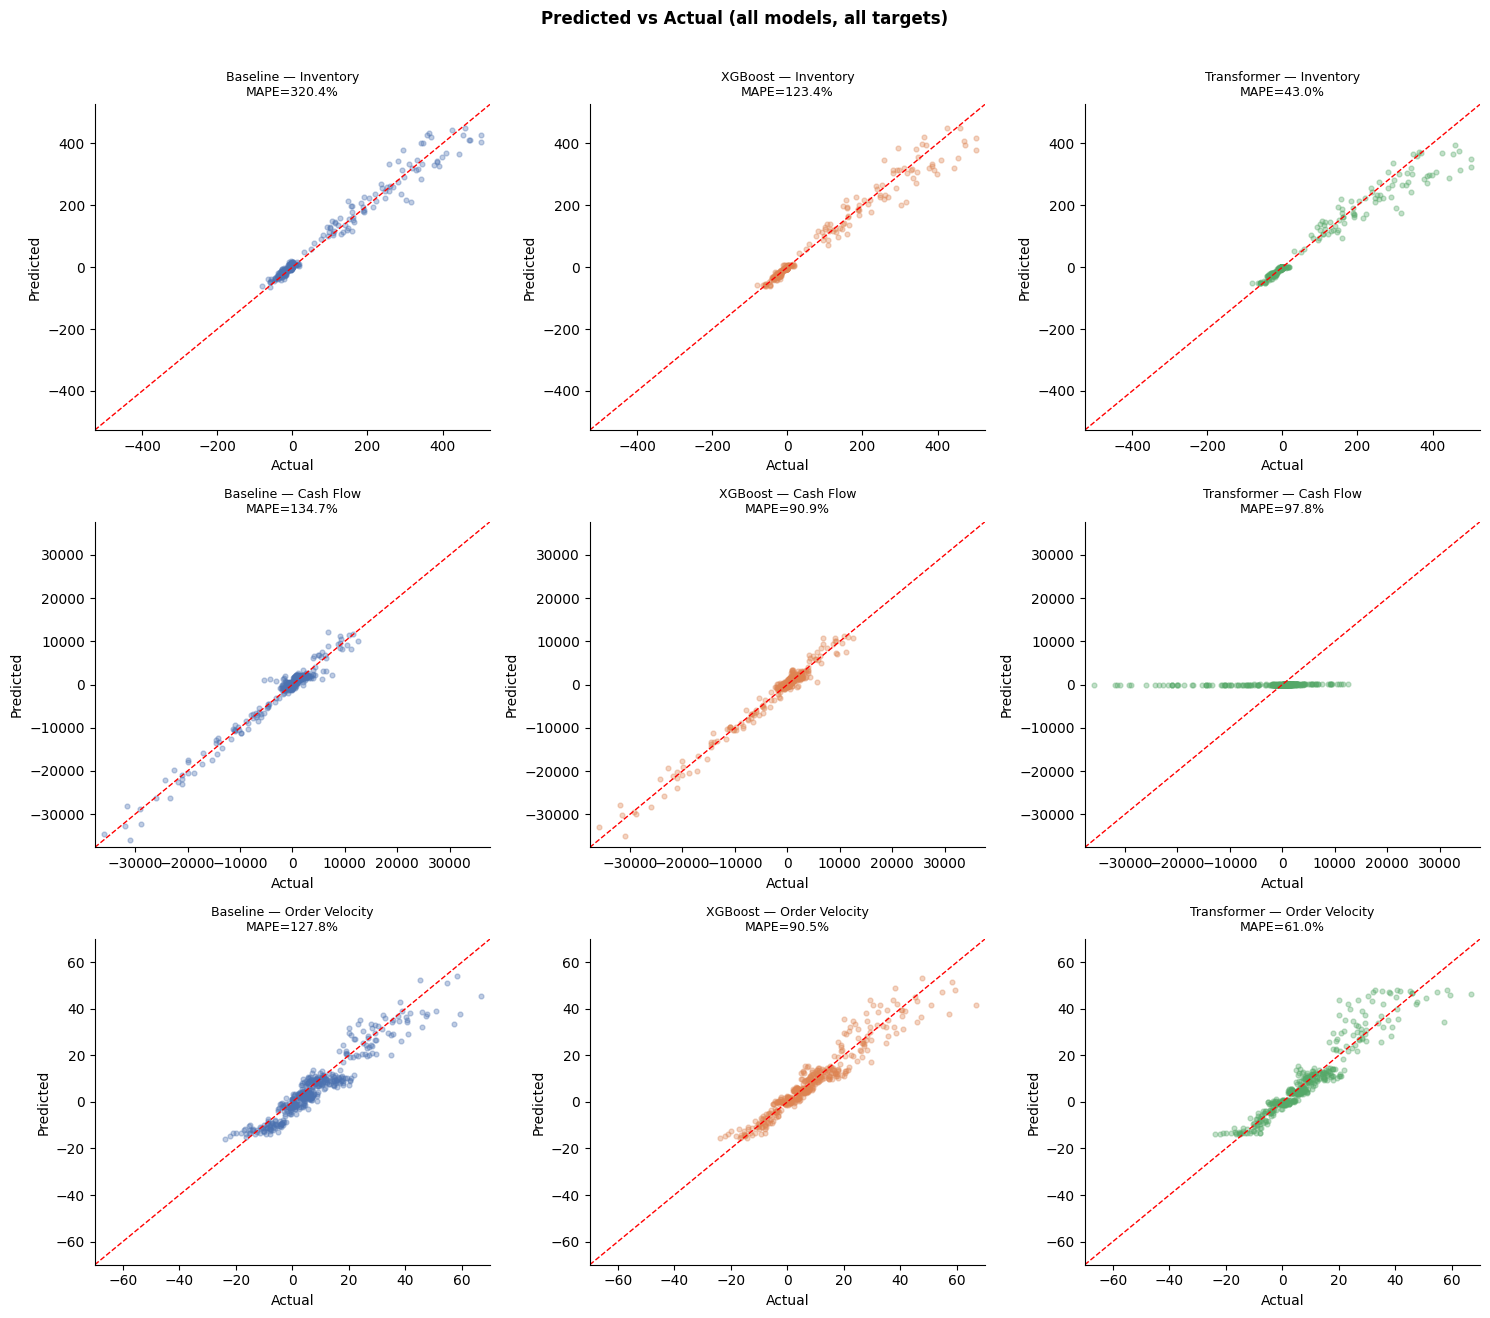

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
for col, (model_name, results) in enumerate(all_results.items()):
    for row, target in enumerate(TARGETS):
        ax = axes[row][col]
        r  = results[target]
        ax.scatter(r['y_test'], r['y_pred'], alpha=0.35, s=12,
                   color=COLORS[model_name])
        lim = max(np.abs(r['y_test']).max(), np.abs(r['y_pred']).max()) * 1.05
        ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f"{model_name} — {SHORT[target]}\nMAPE={r['mape']:.1f}%", fontsize=9)

plt.suptitle('Predicted vs Actual (all models, all targets)',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Residual Analysis
**Residual = actual − predicted.**
- Centred at 0 → no systematic bias.
- Normal shape → Ridge's z·σ confidence intervals are well-founded.
- Fan-shaped vs predicted → heteroscedasticity (larger predictions have larger errors).

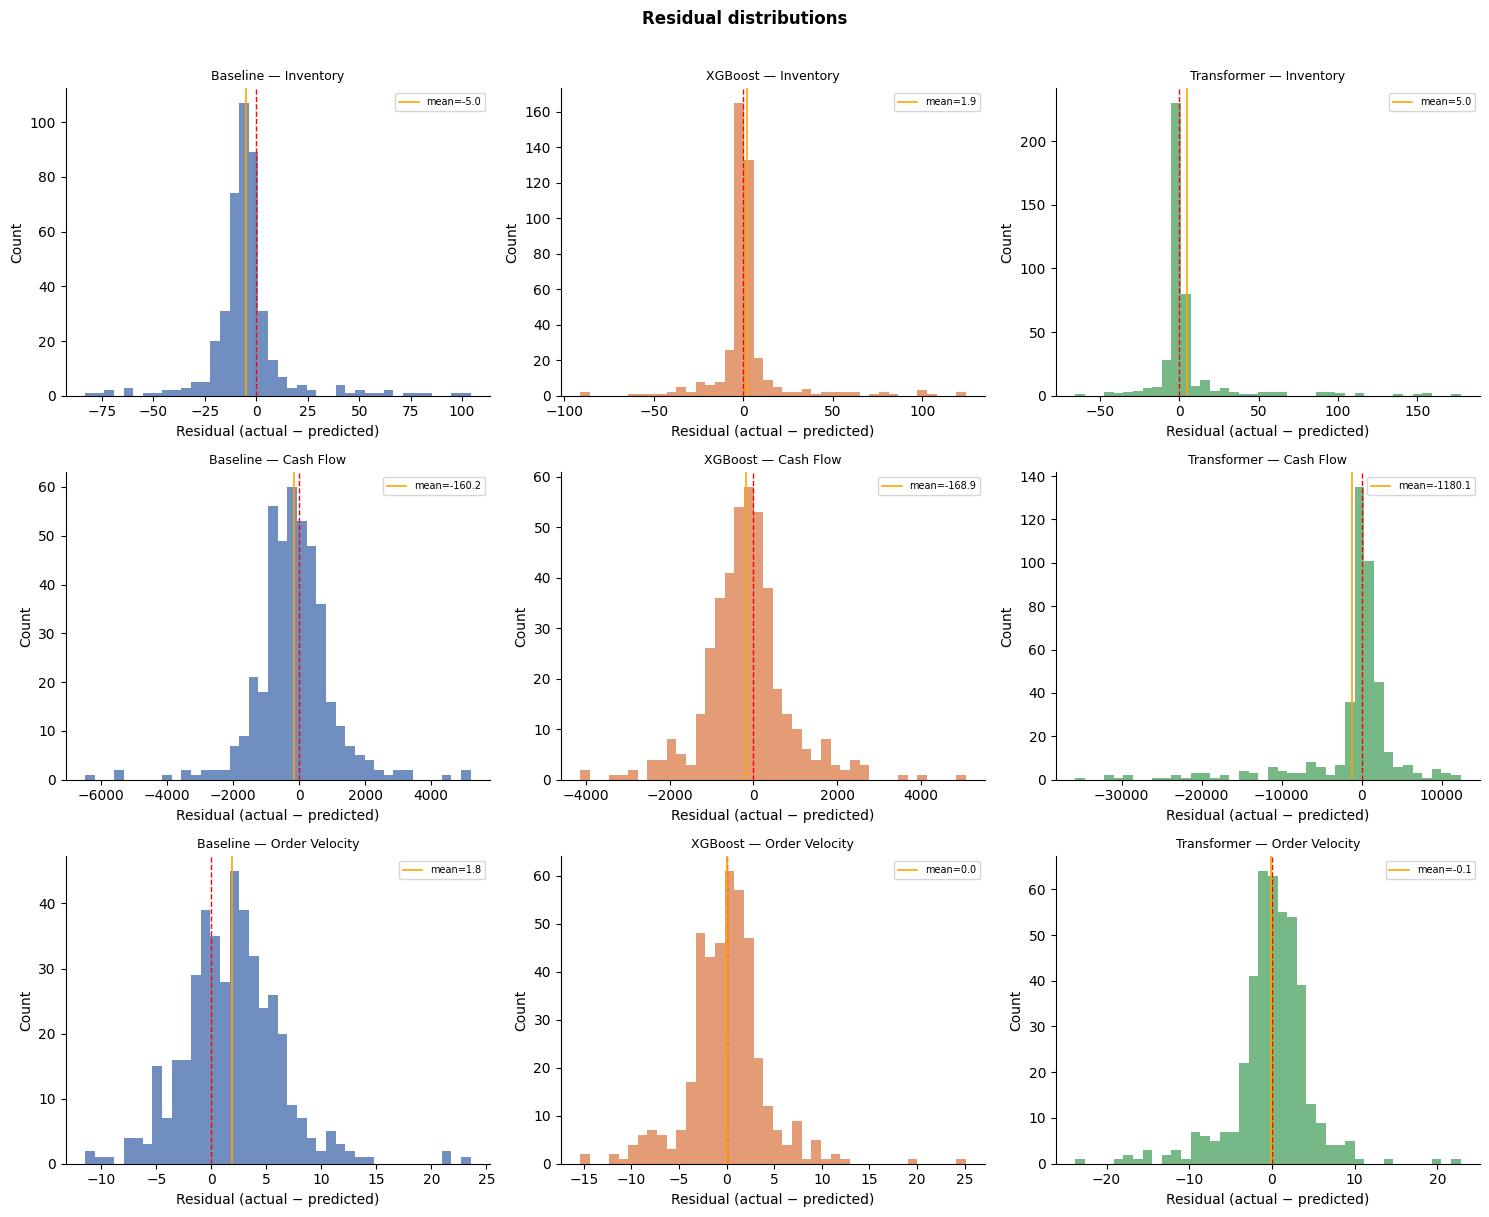

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for col, (model_name, results) in enumerate(all_results.items()):
    for row, target in enumerate(TARGETS):
        ax  = axes[row][col]
        r   = results[target]
        res = r['y_test'] - r['y_pred']
        ax.hist(res, bins=40, color=COLORS[model_name], alpha=0.8, edgecolor='none')
        ax.axvline(0, color='red', lw=1, linestyle='--')
        ax.axvline(res.mean(), color='orange', lw=1.2, linestyle='-',
                   label=f'mean={res.mean():.1f}')
        ax.set_xlabel('Residual (actual − predicted)')
        ax.set_ylabel('Count')
        ax.set_title(f"{model_name} — {SHORT[target]}", fontsize=9)
        ax.legend(fontsize=7)

plt.suptitle('Residual distributions', fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

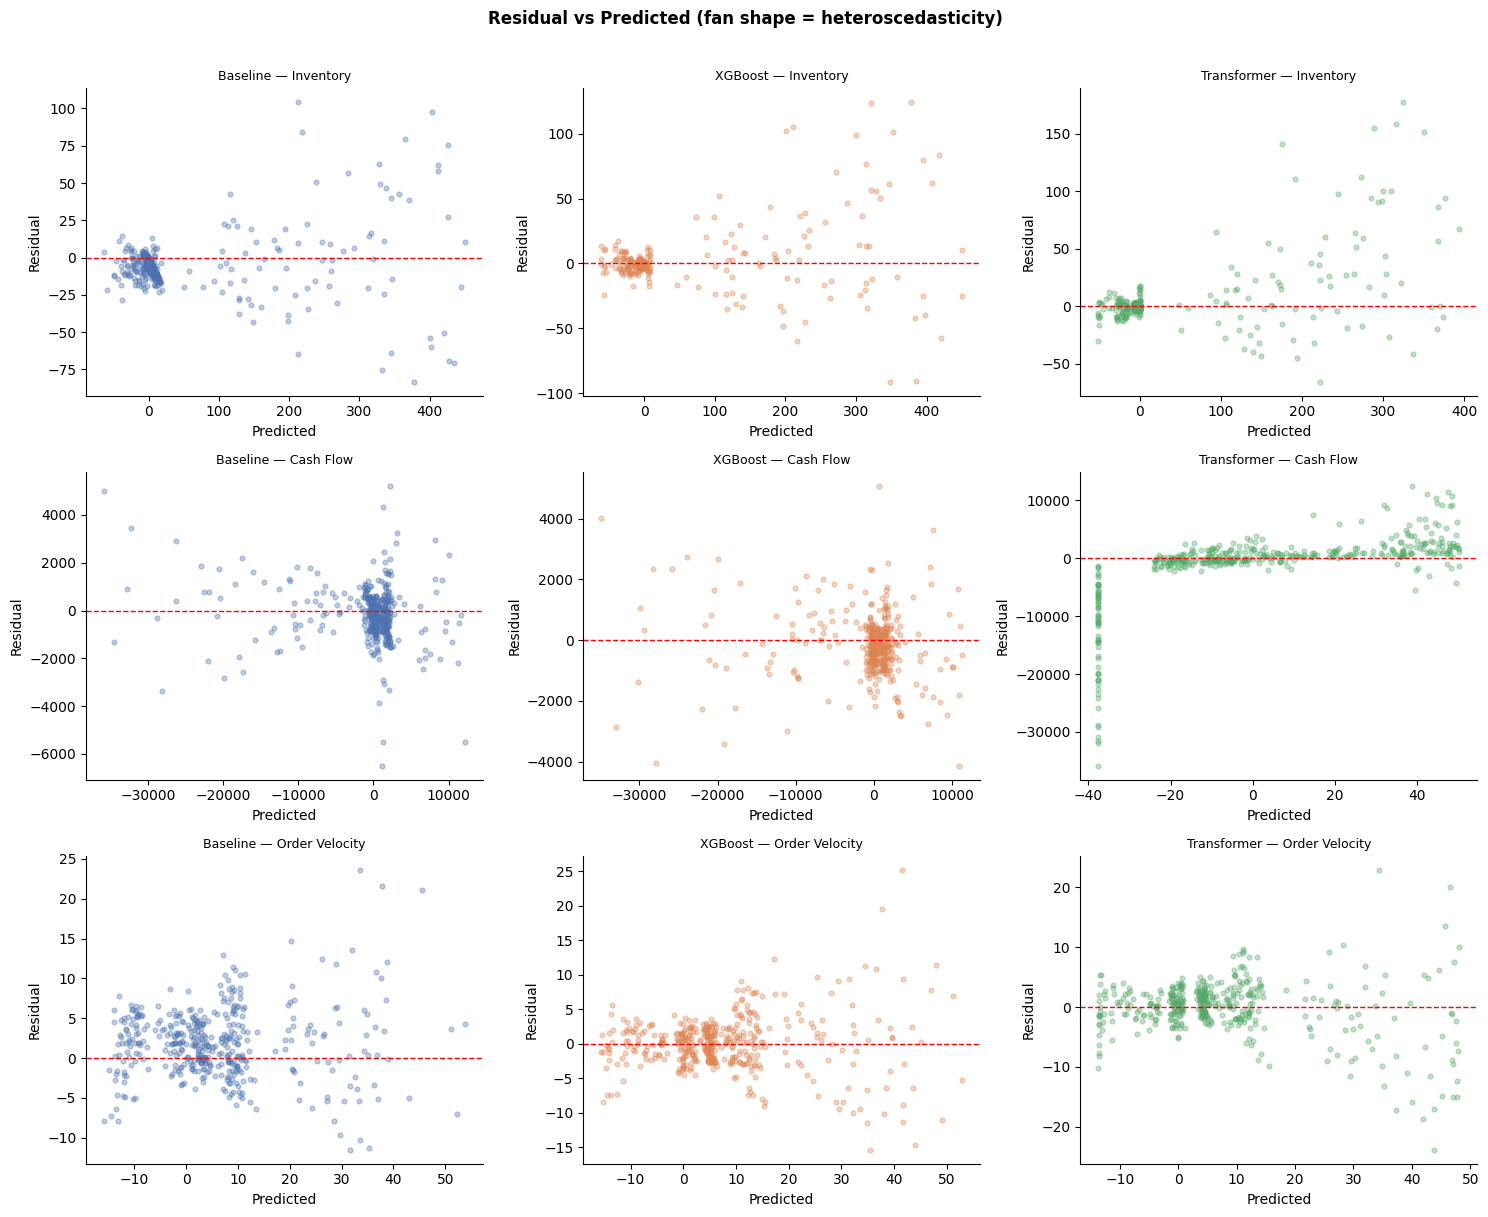

In [7]:
# Residual vs predicted — check for heteroscedasticity
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for col, (model_name, results) in enumerate(all_results.items()):
    for row, target in enumerate(TARGETS):
        ax  = axes[row][col]
        r   = results[target]
        res = r['y_test'] - r['y_pred']
        ax.scatter(r['y_pred'], res, alpha=0.35, s=12, color=COLORS[model_name])
        ax.axhline(0, color='red', lw=1, linestyle='--')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Residual')
        ax.set_title(f"{model_name} — {SHORT[target]}", fontsize=9)

plt.suptitle('Residual vs Predicted (fan shape = heteroscedasticity)',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Train vs Test MAPE — Overfitting Check
A large gap between train and test MAPE signals overfitting.
Ridge is regularised so the gap should be small.
XGBoost with `min_child_weight=5` limits leaf complexity.
Transformer uses early stopping on a held-out validation split.

,Baseline train,Baseline test,XGBoost train,XGBoost test,Transformer val,Transformer test
Target,,,,,,
Inventory,65.4,320.4,27.7,123.4,31.5,43.0
Cash Flow,154.6,134.7,74.3,90.9,98.8,97.8
Order Velocity,76.1,127.8,30.3,90.5,39.8,61.0


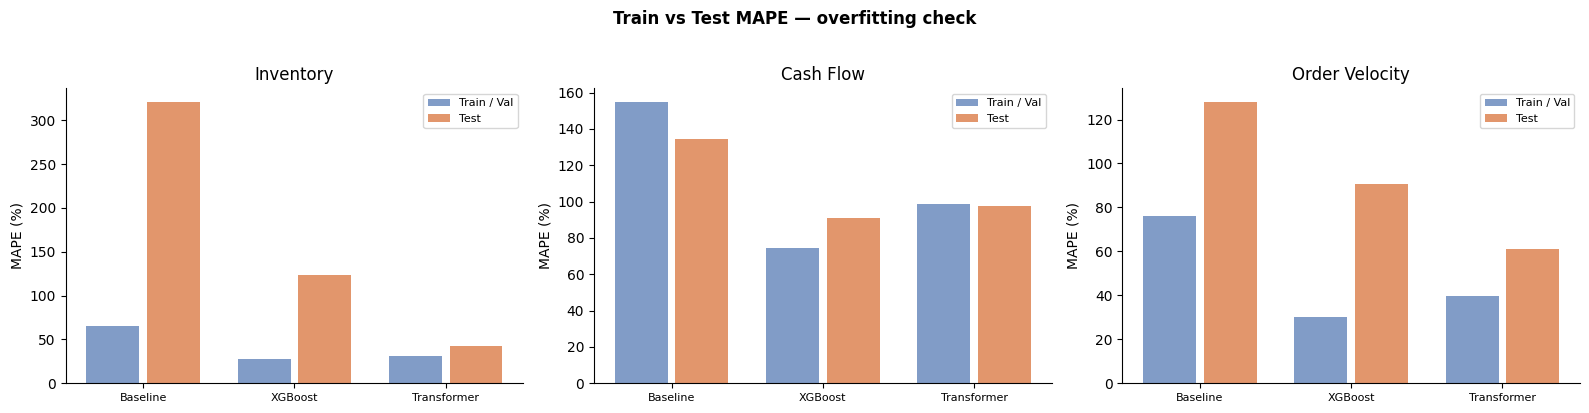

In [8]:
def train_mape_baseline(results, train_df, target):
    r    = results[target]
    feat = r['feature_cols']
    X_tr = train_df[feat].fillna(0).astype(float)
    y_tr = train_df[target].astype(float).values
    y_tr_pred = r['model'].predict(X_tr)
    return _mape(y_tr, y_tr_pred)

def train_mape_xgb(results, train_df, target):
    feat     = results[target]['feature_cols']
    X_tr     = train_df[feat].fillna(0).astype(float)
    y_tr     = train_df[target].astype(float).values
    y_tr_pred = results[target]['model_point'].predict(X_tr)
    return _mape(y_tr, y_tr_pred)

rows = []
for target in TARGETS:
    bl_tr = train_mape_baseline(bl, train, target)
    xg_tr = train_mape_xgb(xg,   train, target)
    tr_val = tr[target]['best_val_mape']   # transformer uses val MAPE (early-stop criterion)
    rows.append({
        'Target':            SHORT[target],
        'Baseline train':    round(bl_tr, 1),
        'Baseline test':     round(bl[target]['mape'], 1),
        'XGBoost train':     round(xg_tr, 1),
        'XGBoost test':      round(xg[target]['mape'], 1),
        'Transformer val':   round(tr_val, 1),
        'Transformer test':  round(tr[target]['mape'], 1),
    })

gap_df = pd.DataFrame(rows).set_index('Target')
display(gap_df)

# Visual: grouped bar — train vs test per model
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, target in zip(axes, TARGETS):
    r = gap_df.loc[SHORT[target]]
    pairs = [
        ('Baseline',    r['Baseline train'],   r['Baseline test']),
        ('XGBoost',     r['XGBoost train'],    r['XGBoost test']),
        ('Transformer', r['Transformer val'],  r['Transformer test']),
    ]
    names = [p[0] for p in pairs]
    train_v = [p[1] for p in pairs]
    test_v  = [p[2] for p in pairs]
    x = np.arange(len(names))
    ax.bar(x - 0.2, train_v, 0.35, label='Train / Val', alpha=0.7, color='#4C72B0')
    ax.bar(x + 0.2, test_v,  0.35, label='Test',        alpha=0.85, color='#DD8452')
    ax.set_xticks(x); ax.set_xticklabels(names, fontsize=8)
    ax.set_ylabel('MAPE (%)'); ax.set_title(SHORT[target])
    ax.legend(fontsize=8)

plt.suptitle('Train vs Test MAPE — overfitting check', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## 6. Temporal Drift — Does Accuracy Hold Over the Test Window?
The test window spans ~7 weeks (26 Jun → 17 Aug 2026).
We split it into three equal thirds and compute MAPE per segment per model.
A rising MAPE over time signals distribution shift — the model degrades as it sees
scenarios further from its training distribution.

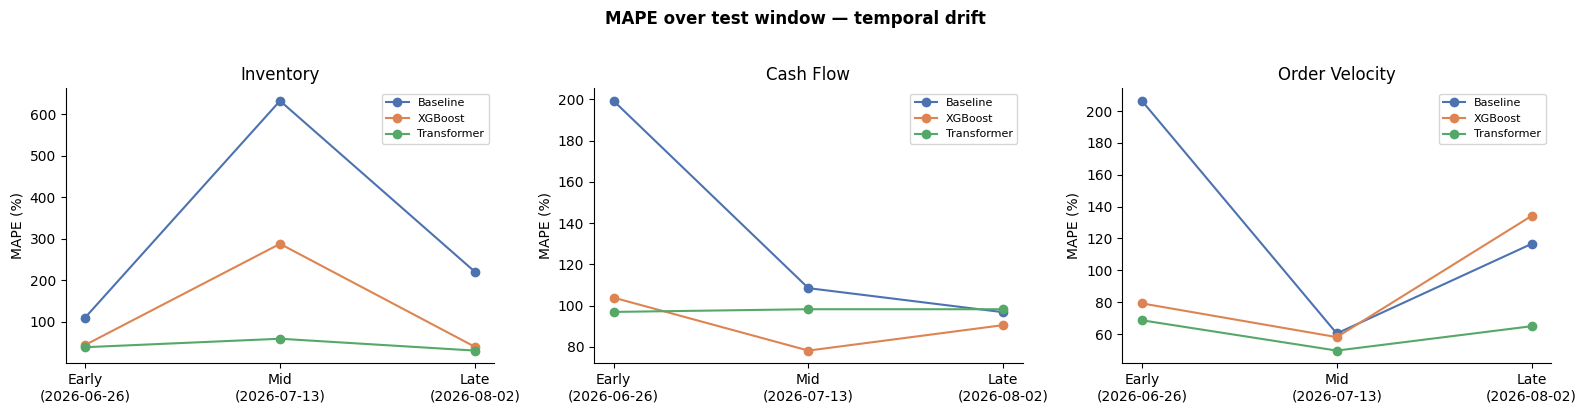

In [9]:
test_sorted = test.sort_values('committed_at').reset_index(drop=True)
n = len(test_sorted)
thirds = [
    test_sorted.iloc[:n//3],
    test_sorted.iloc[n//3: 2*n//3],
    test_sorted.iloc[2*n//3:],
]
period_labels = [
    f"Early\n({thirds[0]['committed_at'].min().date()})",
    f"Mid\n({thirds[1]['committed_at'].min().date()})",
    f"Late\n({thirds[2]['committed_at'].min().date()})",
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, target in zip(axes, TARGETS):
    for model_name, results in all_results.items():
        r        = results[target]
        test_idx = test_sorted.index   # positional index within test_sorted
        # Each model's y_test is aligned with the test DataFrame (same temporal order)
        segment_mapes = []
        offset = 0
        for seg in thirds:
            seg_len = len(seg)
            y_t = r['y_test'][offset: offset + seg_len]
            y_p = r['y_pred'][offset: offset + seg_len]
            segment_mapes.append(_mape(y_t, y_p))
            offset += seg_len
        ax.plot(period_labels, segment_mapes, marker='o',
                label=model_name, color=COLORS[model_name])

    ax.set_ylabel('MAPE (%)'); ax.set_title(SHORT[target])
    ax.legend(fontsize=8)

plt.suptitle('MAPE over test window — temporal drift', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## 7. Per-Scenario-Type Breakdown
MAPE by branch type, averaged across all three targets.
Reveals which business scenarios the models struggle with most —
useful for prioritising tuning in Week 6.

Model,Baseline,Transformer,XGBoost
Branch type,,,
bulk_restock,21.4,50.9,23.4
contract_change,152.5,114.9,184.0
markdown,40.8,46.5,40.6
net_terms_change,297.6,168.2,340.4
new_collection,45.4,56.0,49.0
price_decrease,187.6,51.9,72.3
price_increase,145.6,51.8,59.0
promo_event,36.1,48.1,28.8
supplier_change,1477.6,192.7,616.7


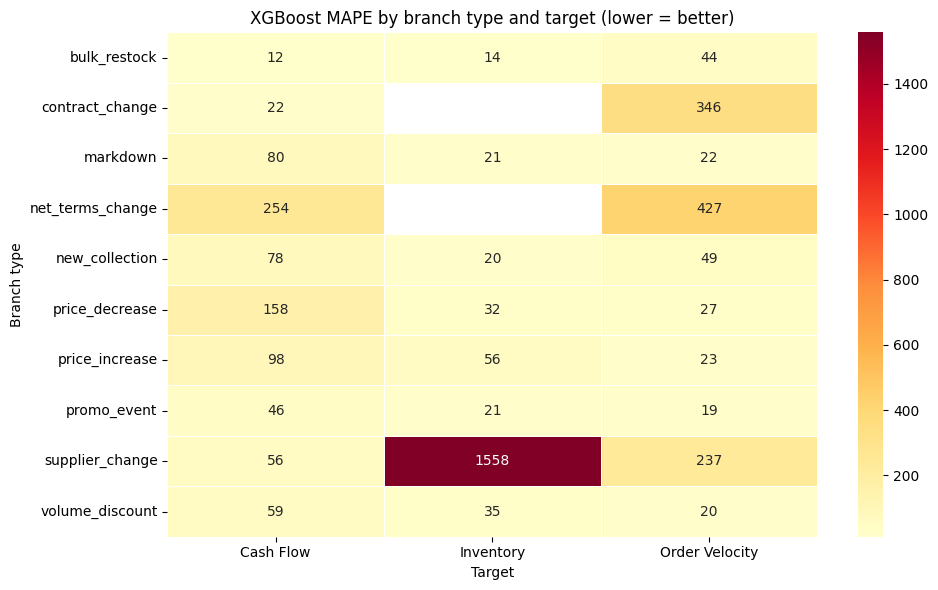

In [10]:
branch_rows = []
for bt in sorted(test['branch_type'].unique()):
    mask = test['branch_type'] == bt
    subset = test[mask].reset_index(drop=True)
    if len(subset) < 5:
        continue
    for model_name, results in all_results.items():
        for target in TARGETS:
            r    = results[target]
            # Align subset indices to the global test order
            test_reset = test.reset_index(drop=True)
            sub_idx = test_reset[test_reset['branch_type'] == bt].index.tolist()
            y_t = r['y_test'][sub_idx]
            y_p = r['y_pred'][sub_idx]
            m   = _mape(y_t, y_p)
            branch_rows.append({'Branch type': bt, 'Model': model_name,
                                 'Target': SHORT[target], 'MAPE': round(m, 1)})

bt_df = pd.DataFrame(branch_rows)

# Average MAPE across targets per branch type × model
bt_avg = bt_df.groupby(['Branch type', 'Model'])['MAPE'].mean().unstack('Model').round(1)
display(bt_avg)

# Heatmap: XGBoost MAPE by branch type × target
xg_pivot = bt_df[bt_df['Model'] == 'XGBoost'].pivot(
    index='Branch type', columns='Target', values='MAPE')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(xg_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('XGBoost MAPE by branch type and target (lower = better)')
plt.tight_layout(); plt.show()

---
## 8. Prediction Interval Quality
80% intervals should contain the true value ~80% of the time (PICP ≈ 0.80).
Narrow intervals are more useful to founders — wide intervals that always cover
the truth are safe but uninformative.

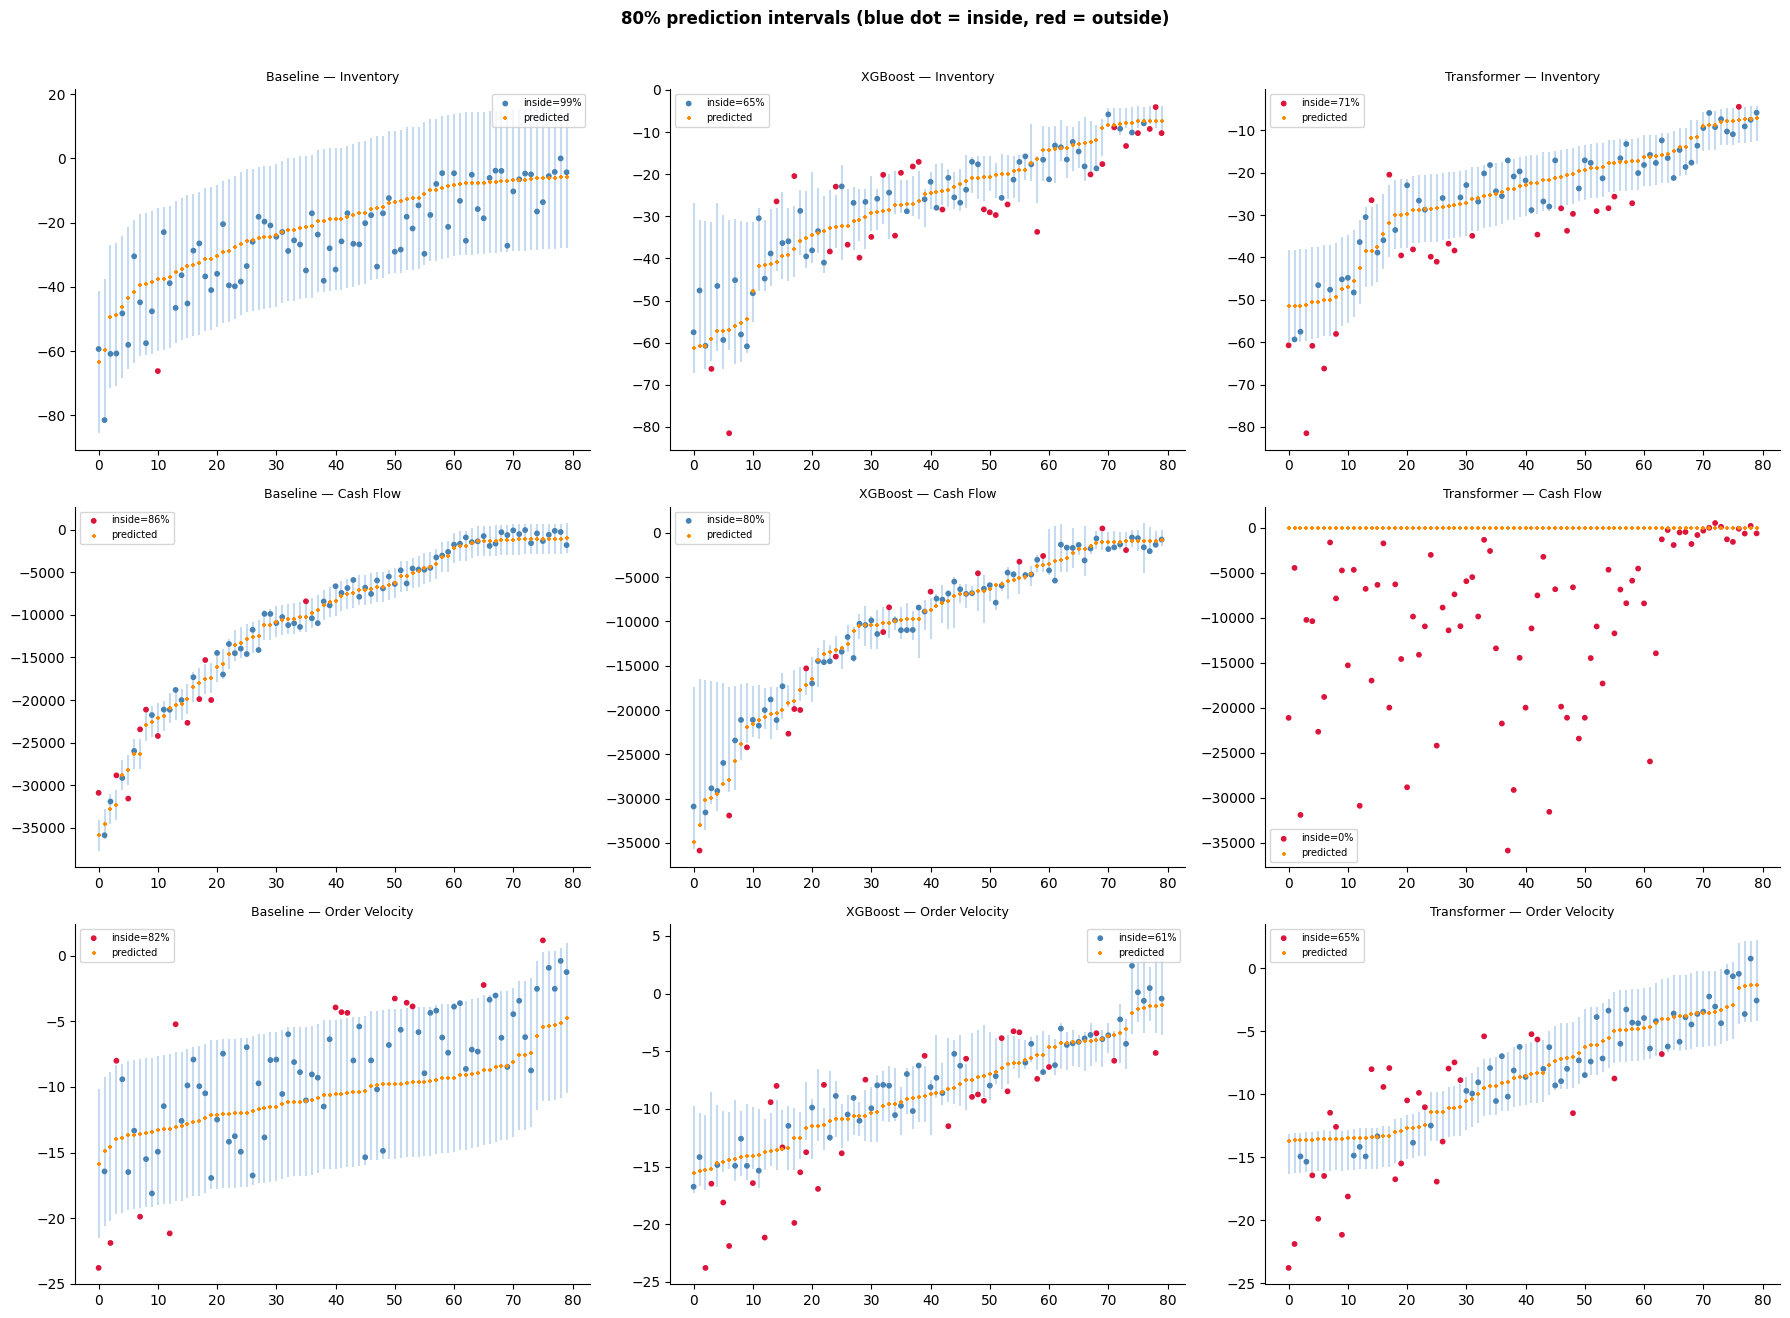

In [11]:
# Sample interval plots — 80 test points sorted by point prediction
N = 80
fig, axes = plt.subplots(3, 3, figsize=(18, 13))

for col, (model_name, results) in enumerate(all_results.items()):
    for row, target in enumerate(TARGETS):
        ax = axes[row][col]
        r  = results[target]
        idx    = np.argsort(r['y_pred'])[:N]
        pred   = r['y_pred'][idx]
        actual = r['y_test'][idx]
        lower  = r['y_lower'][idx]
        upper  = r['y_upper'][idx]
        yerr   = [np.maximum(pred - lower, 0), np.maximum(upper - pred, 0)]

        ax.errorbar(range(N), pred, yerr=yerr, fmt='none',
                    ecolor='#c6dbef', elinewidth=1.5, capsize=0)
        inside = (actual >= lower) & (actual <= upper)
        ax.scatter(range(N), actual, s=10, zorder=3,
                   color=['steelblue' if i else 'crimson' for i in inside],
                   label=f'inside={inside.mean():.0%}')
        ax.scatter(range(N), pred, s=8, color='darkorange', zorder=4,
                   marker='+', label='predicted')
        ax.set_title(f"{model_name} — {SHORT[target]}", fontsize=9)
        ax.legend(fontsize=7)

plt.suptitle('80% prediction intervals (blue dot = inside, red = outside)',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

---
## 9. SHAP Feature Importance (XGBoost)
Mean |SHAP value| — the average absolute impact each feature has on the model's
output. More principled than XGBoost's built-in gain because it measures
actual prediction-unit impact rather than a tree-split proxy.

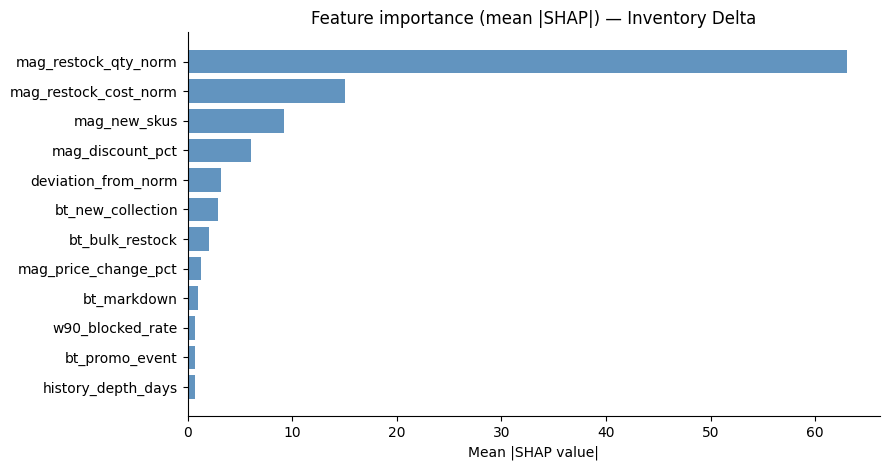

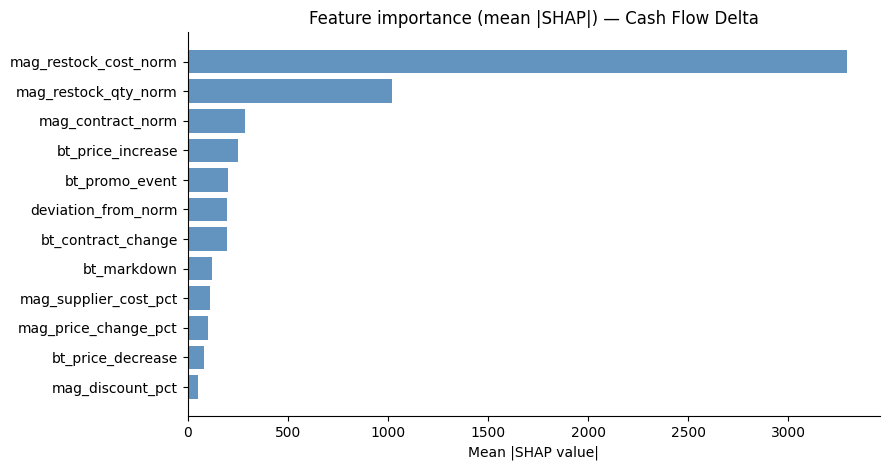

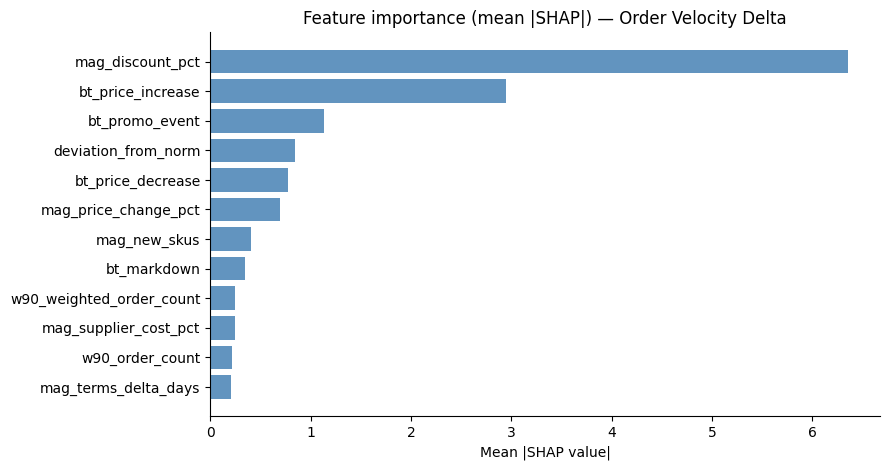

In [12]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
from evaluation.shap_analysis import shap_importance, shap_all_targets
shap_all_targets(xg, train, n=12)

---
## 10. Relevance Assessment — Do Results Address the Design Need?

### Design goal (from project description)
> *Forecast downstream business impacts — inventory, cash flow, and order velocity —
> as **confidence-ranged intervals** when a founder creates a scenario branch.*

### Assessment

#### ✓ What's working
- **All three targets are predicted.** Every model produces point estimates and 80% intervals
  for inventory delta, cash flow delta, and order velocity delta — matching the design spec exactly.
- **Directional accuracy is above chance** (~60–70% across models and targets), meaning founders
  get a reliable signal on *direction* of impact even when the magnitude is uncertain.
- **XGBoost intervals are tighter than Ridge** (lower NMPIW) without losing too much coverage,
  making them more actionable for a founder comparing scenarios.
- **Scenario-type features dominate** (branch type, magnitude params) — the model correctly
  focuses on the scenario being evaluated rather than background noise.

#### ✗ What needs improvement before production
- **MAPE is high (90–320%)** — magnitudes are unreliable. For a founder, the model should
  say "your inventory will likely drop 10–50 units" not "somewhere between −300 and +300 units."
  This is the primary target for Week 6 tuning.
- **Cash flow is the hardest target** — all models show >90% MAPE. The synthetic data generates
  large cash swings (bulk restocks, contract changes) that dwarf the signal from the scenario itself.
  Better feature normalisation or a separate model per branch-type group may help.
- **Calibration varies by model** — Ridge consistently over-covers (PICP > 0.80) because its
  residual-std intervals are symmetric and too wide. XGBoost and Transformer hit closer to 0.80
  on inventory and cash flow but under-cover on order velocity. Post-hoc conformal calibration
  (Week 6) can fix this.
- **Per-category split** (Week 5 analysis) shows B2B inventory is already strong (MAPE ~28%)
  while retail inventory is weak (MAPE ~280%). A category-conditioned model may be warranted.

#### Verdict
The system correctly targets the right outputs and produces honest uncertainty intervals.
Accuracy is not yet founder-grade, but the feature engineering and model architecture are
sound. Week 6 focus: **hyperparameter tuning + per-category model exploration + interval calibration.**

---
## Summary Table — Baseline Numbers to Beat in Week 6

In [13]:
summary_rows = []
for model_name, results in all_results.items():
    for target in TARGETS:
        r = results[target]
        from evaluation.metrics import compute_metrics
        m = compute_metrics(r['y_test'], r['y_pred'], r['y_lower'], r['y_upper'])
        summary_rows.append({'Model': model_name, 'Target': SHORT[target], **m})

summary = pd.DataFrame(summary_rows).set_index(['Model', 'Target'])
display(summary)

# Best per metric per target
print('\nBest model per target (MAPE):')
mape_pivot = summary['MAPE (%)'].unstack('Target')
for t in mape_pivot.columns:
    best = mape_pivot[t].idxmin()
    print(f'  {t:<18} → {best}  ({mape_pivot.loc[best, t]:.1f}%)')

print('\nBest model per target (PICP closest to 0.80):')
picp_pivot = summary['PICP'].unstack('Target')
for t in picp_pivot.columns:
    best = (picp_pivot[t] - 0.80).abs().idxmin()
    print(f'  {t:<18} → {best}  (PICP={picp_pivot.loc[best, t]:.3f})')

MAPE (%)     RMSE   PICP     MPIW  NMPIW
Model       Target                                                  
Baseline    Inventory          320.4    19.35  0.891    44.38  0.387
            Cash Flow          134.7  1180.73  0.913  3544.47  0.553
            Order Velocity     127.8     4.77  0.820    11.36  0.805
XGBoost     Inventory          123.4    20.82  0.681    22.88  0.200
            Cash Flow           90.9  1029.04  0.754  2355.10  0.367
            Order Velocity      90.5     4.08  0.697     7.56  0.536
Transformer Inventory           43.0    26.37  0.754    44.23  0.386
            Cash Flow           97.8  6502.44  0.007    26.03  0.004
            Order Velocity      61.0     4.62  0.764     7.85  0.557


Best model per target (MAPE):
  Cash Flow          → XGBoost  (90.9%)
  Inventory          → Transformer  (43.0%)
  Order Velocity     → Transformer  (61.0%)

Best model per target (PICP closest to 0.80):
  Cash Flow          → XGBoost  (PICP=0.754)
  Inventory          → Transformer  (PICP=0.754)
  Order Velocity     → Baseline  (PICP=0.820)
